# SWGO L07 Detector Optimization (Refactored)

All utility functions have been extracted into separate Python modules.
This notebook preserves the original optimization logic.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import copy
import warnings
import matplotlib.patches as patches
from pathlib import Path
from matplotlib import colors
from matplotlib.colors import LogNorm, Normalize
from torch.utils.data import TensorDataset, DataLoader
import os

# Extracted module imports
from shower_generation import GenerateShowers
from detector_response import GetCounts_differentiable, SmearN, TimeAverage_vectorized
from geometry import Layouts
from reconstruction import Reconstruction, NormalizeLabels, DenormalizeLabels, EarlyStopping
from layout_optimization import LearnableXY, push_apart, symmetry_loss
from utility_functions import reconstructability, U_PR, U_E, U_TH

output_dir = "./outputs/NN_Files_14_updated_padding_20k"
os.makedirs(output_dir, exist_ok=True)

## Constants and Parameters

In [3]:
# Matrices used in shower parametrization
A = torch.tensor([[1, 1, 1, 1],[1, 2, 4, 8], [1, 3, 9, 27], [1, 4, 16, 64]], dtype=torch.float32)

# Constants
c0 = .29979  # Speed of light in [m / ns]
theta_max = np.pi * 65 / 180
log_01 = torch.tensor([np.log(.1)], dtype=torch.float32)
log_10 = torch.tensor([np.log(10)], dtype=torch.float32)
sqrt12 = torch.tensor([np.sqrt(12)], dtype=torch.float32)

# Tank Values
IntegrationWindow = 128.  # 128 ns integration window, SWGO default
sigma_time = 10.  # Time resolution assumed for the detectors
R_min = 2.
TankArea = 6.859 * np.pi  # Area for 19 hexagonal macro unit
TankRadius = np.sqrt(6.859)  # Radius of macro unit

# Background
Bgr_mu_per_m2 = 0.000001826 * IntegrationWindow
fluxB_m = torch.tensor([TankArea * Bgr_mu_per_m2])
Bgr_e_per_m2 = 0.000000200 * IntegrationWindow
fluxB_e = torch.tensor([TankArea * Bgr_e_per_m2])

# Sizes
Nunits = 500
RelResCounts = .05

# Debug Parameters
largenumber = 1e13
epsilon = 1 / largenumber

# NN
Nevents = 20000#0
Nvalidation = 2000#0

# Layout
SWGOopt = False
x, y = Layouts(n_detectors=Nunits, n_rings=20, radius=300, center=(300,0))
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# shower denormalization stats
STATS_PATH = '/n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/pre_processed_3rd_step/standardization_stats_train_only.pt'

## Initialize Diffusion Model

In [4]:
from diffusion_model.tambo_3D_diffusion_generator import PlaneDiffusionEvaluator

generator = PlaneDiffusionEvaluator(
    data_dir="/n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/pre_processed_3rd_step/",
    checkpoint_path="/n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/checkpoints/tam_unet/epoch_epoch=1229-val_loss_val_loss=0.0333.ckpt",
    ddim_steps=20,
    eta=0.0,
    guidance_w=1.8,
    imports_path="/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/hhanif/tambo_optimization/unet"
)
generator.load_model()

Initialized PlaneDiffusionEvaluator
Device: cuda:0


Model parameters: 12,408,387
Loaded checkpoint: /n/netscratch/arguelles_delgado_lab/Everyone/hhanif/tambo_simulation_nov_25/checkpoints/tam_unet/epoch_epoch=1229-val_loss_val_loss=0.0333.ckpt
DDIM sampler built (ddim_steps=20, eta=0.0, w=1.8)
Model loading time: 2.13s


In [5]:
from diffusion_model.tambo_3D_fnn_scaler import PlaneFNNGenerator

scaler = PlaneFNNGenerator(
    data_dir="/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_3rd_step_min_50/",
    checkpoint_path="/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/checkpoints/tam_fnn/last.ckpt",
    output_dir="fnn_outputs",
    imports_path="/n/home05/zdimitrov/tambo/TambOpt/ml/scaling_NN/FNN/"
)
scaler.load_model()

Initialized PlaneFNNGenerator
Device: cuda:0
Output directory: fnn_outputs
Loaded standardization stats from: /n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_3rd_step_min_50/global_bbox_stats.pt
  Mean: 90.71444702148438
  Std: 140.77218627929688
Model parameters: 3,751,008
Loaded checkpoint: /n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/checkpoints/tam_fnn/last.ckpt
Using EMA weights for inference
Model parameters: 3,751,008
Model loading time: 0.18s


## Helper: Wrap GenerateShowers with module dependencies

In [6]:
# Create wrapped versions that capture the global dependencies
import functools

_SmearN = functools.partial(SmearN, RelResCounts=RelResCounts)
_TimeAverage = functools.partial(TimeAverage_vectorized,
                                  IntegrationWindow=IntegrationWindow,
                                  sigma_time=sigma_time)
_GetCounts = functools.partial(GetCounts_differentiable,
                                SmearN_fn=_SmearN,
                                fluxB_e=fluxB_e,
                                TimeAverage_vectorized_fn=_TimeAverage)

def generate_showers(x, y, log=False, number_of_showers=1):
    return GenerateShowers(x, y, generator, scaler, _GetCounts, _SmearN, fluxB_e,
                           log=log, number_of_showers=number_of_showers, stats_path=STATS_PATH)

## Visualize Initial Layout

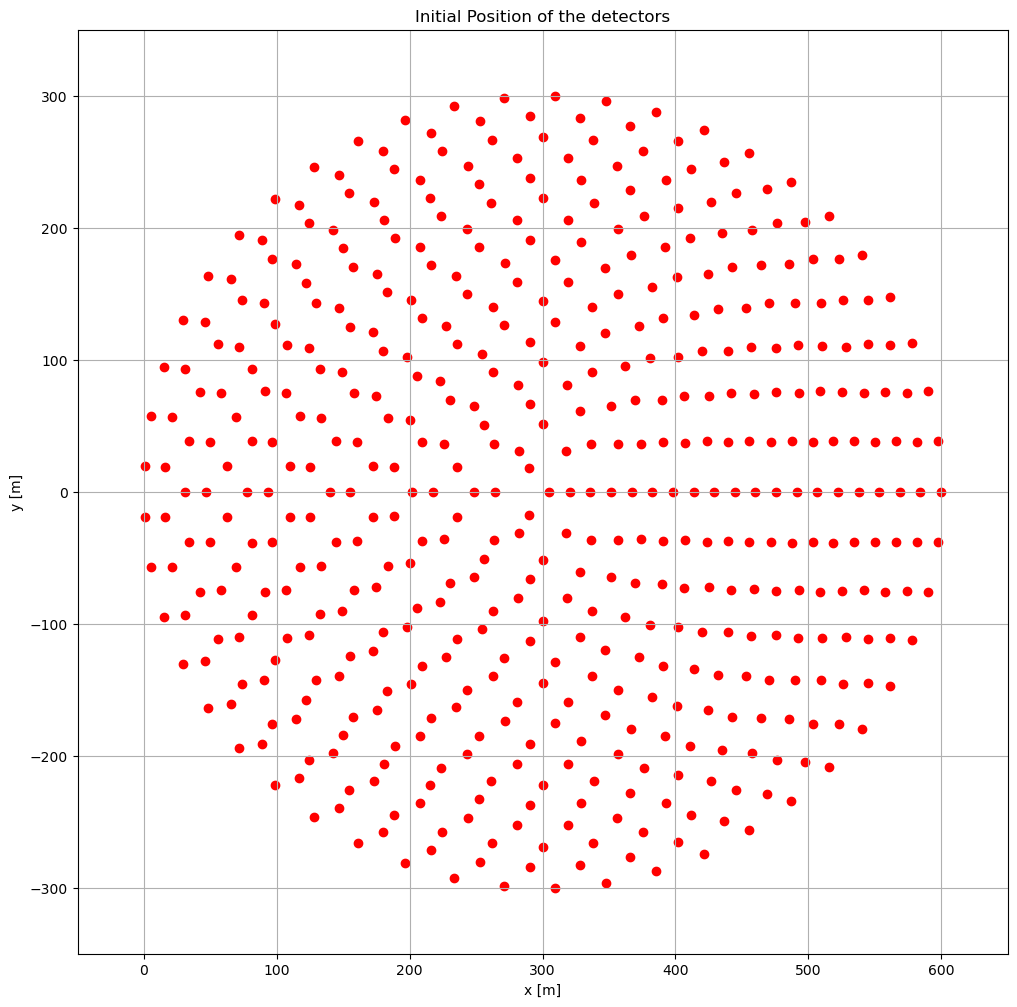

In [7]:
plt.figure(figsize=[12, 12])
plt.scatter(x.detach(), y.detach(), color="red")
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Initial Position of the detectors")
plt.xlim((-50, 650))
plt.ylim((-350, 350))
plt.show()

## Generate and Visualize a Single Shower

Processing conditions 0 to 10 / 10...


✔ Done: generated 10 showers across 10 conditions.
Total generation time: 17.43s
Done: generated 10 bbox predictions across 10 conditions.
Total generation time: 0.09s


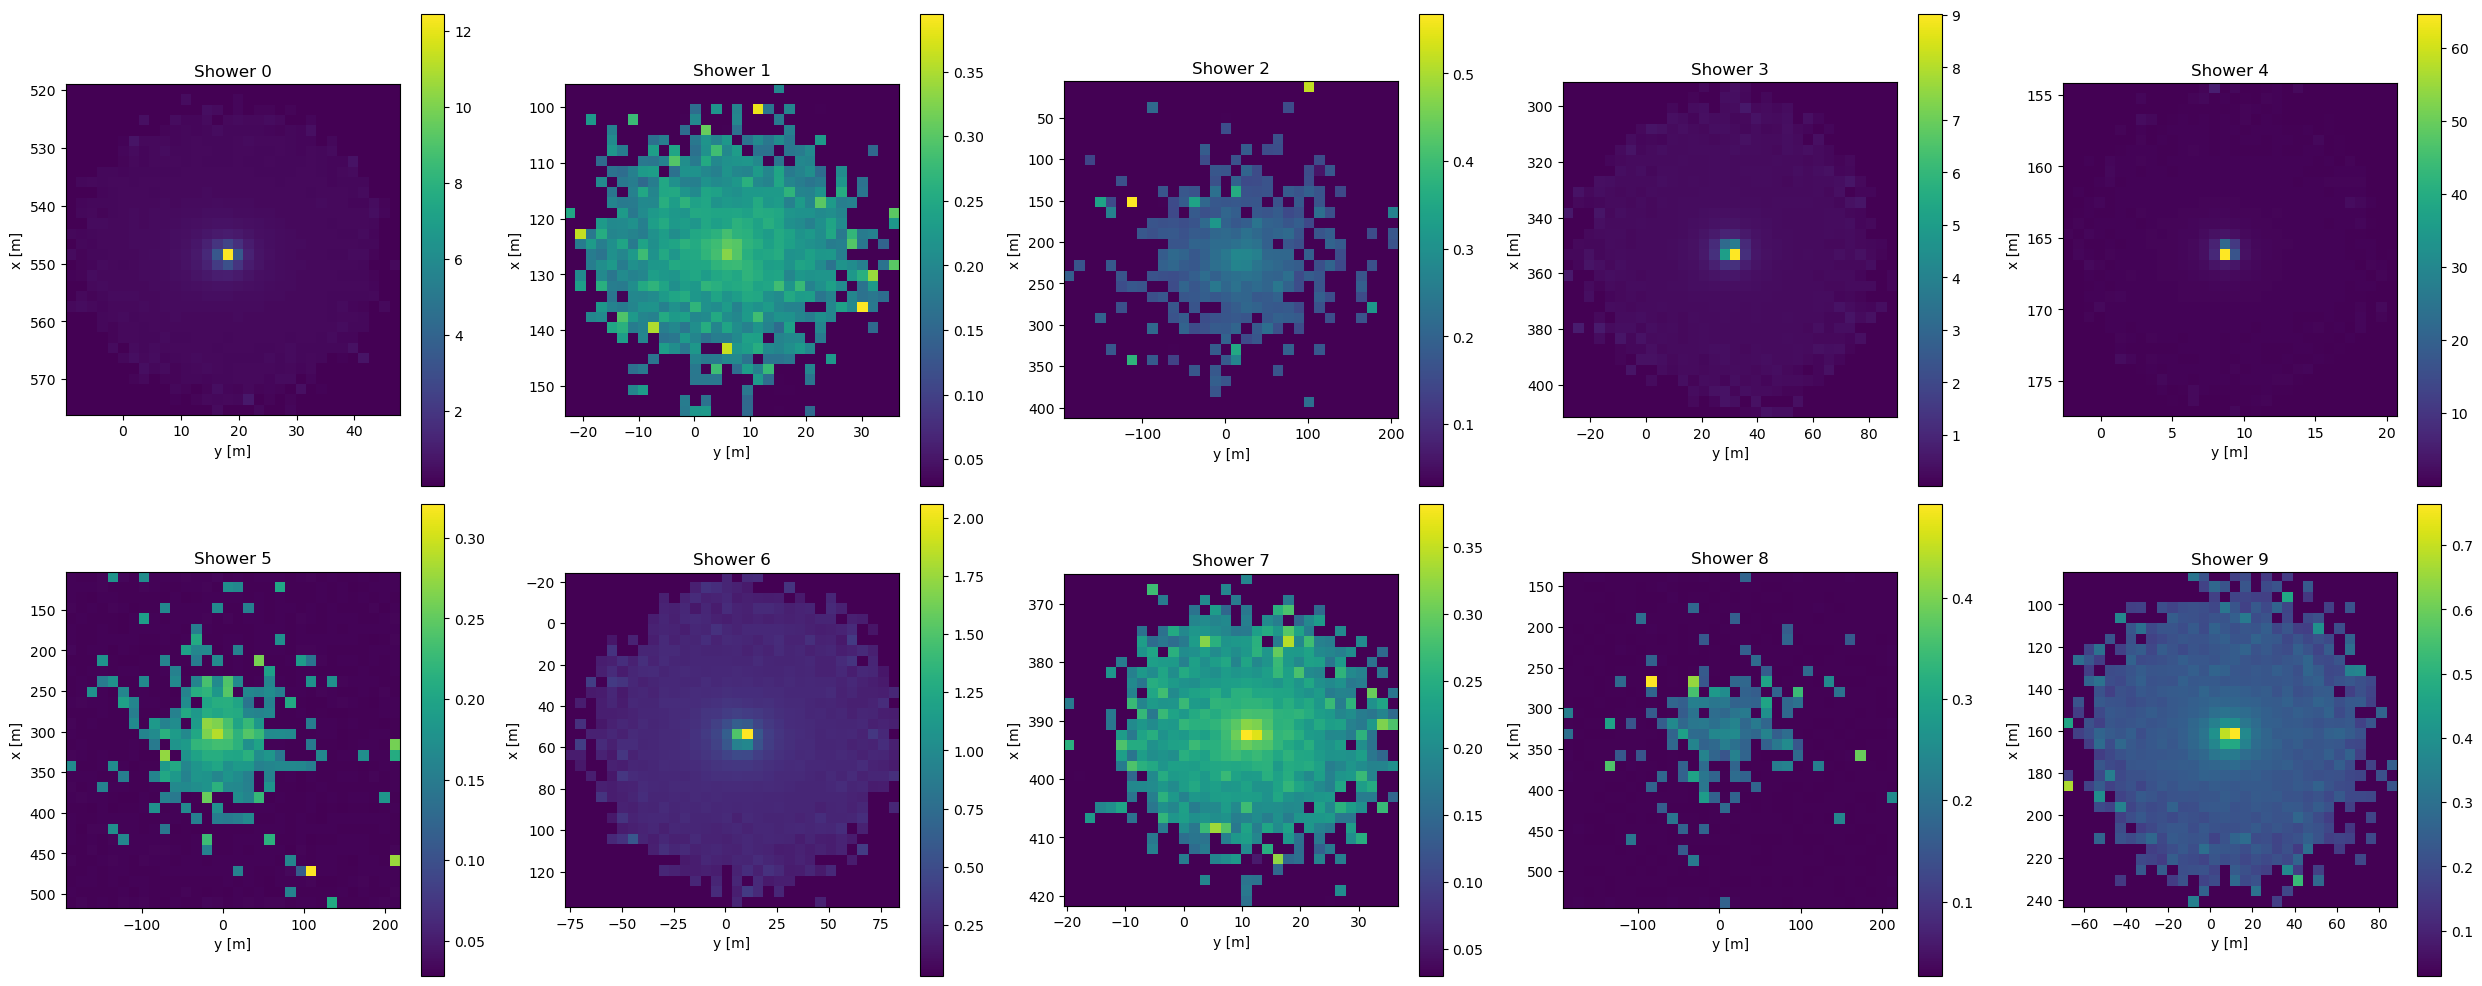

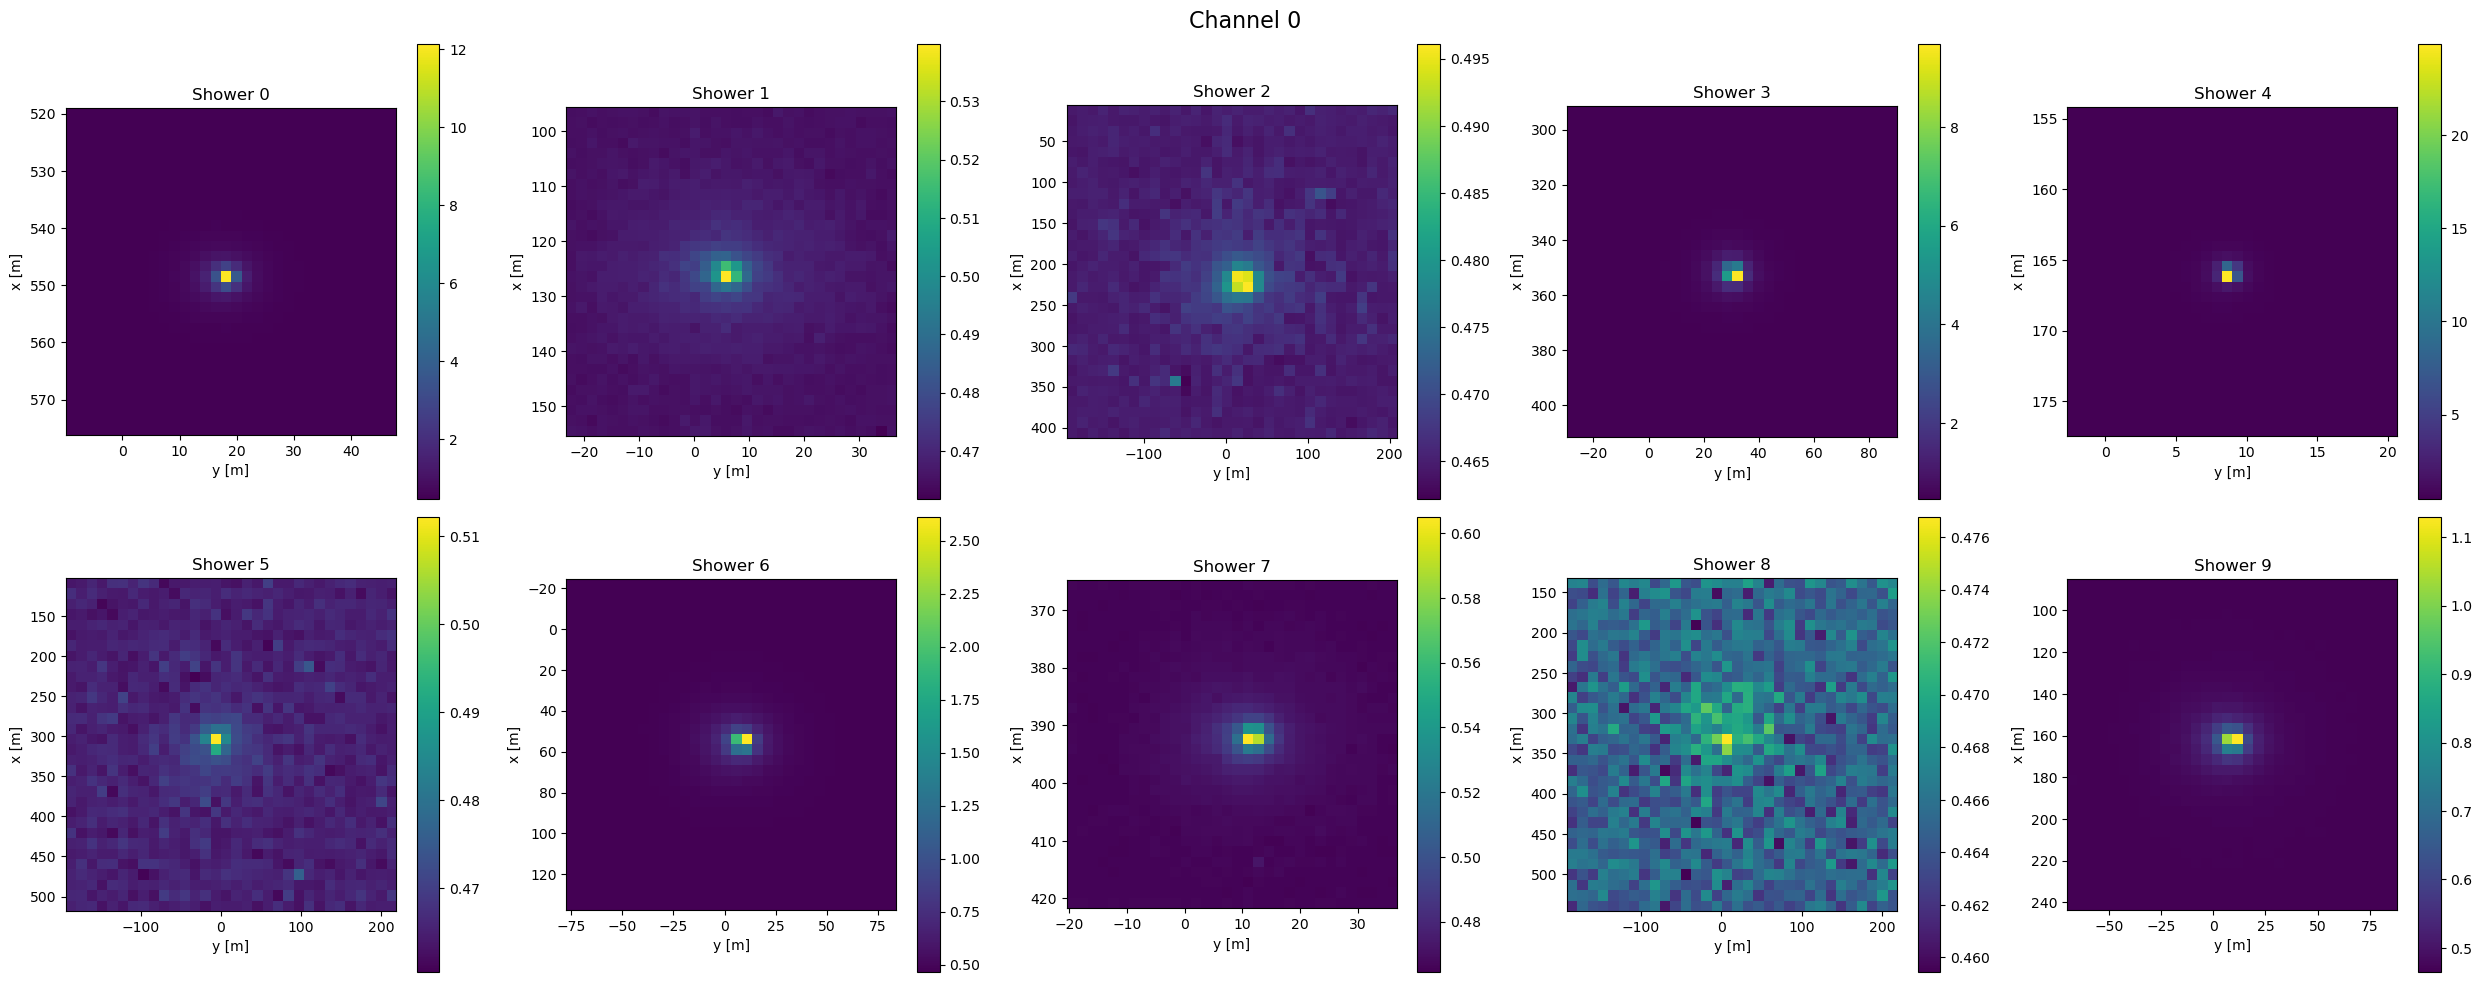

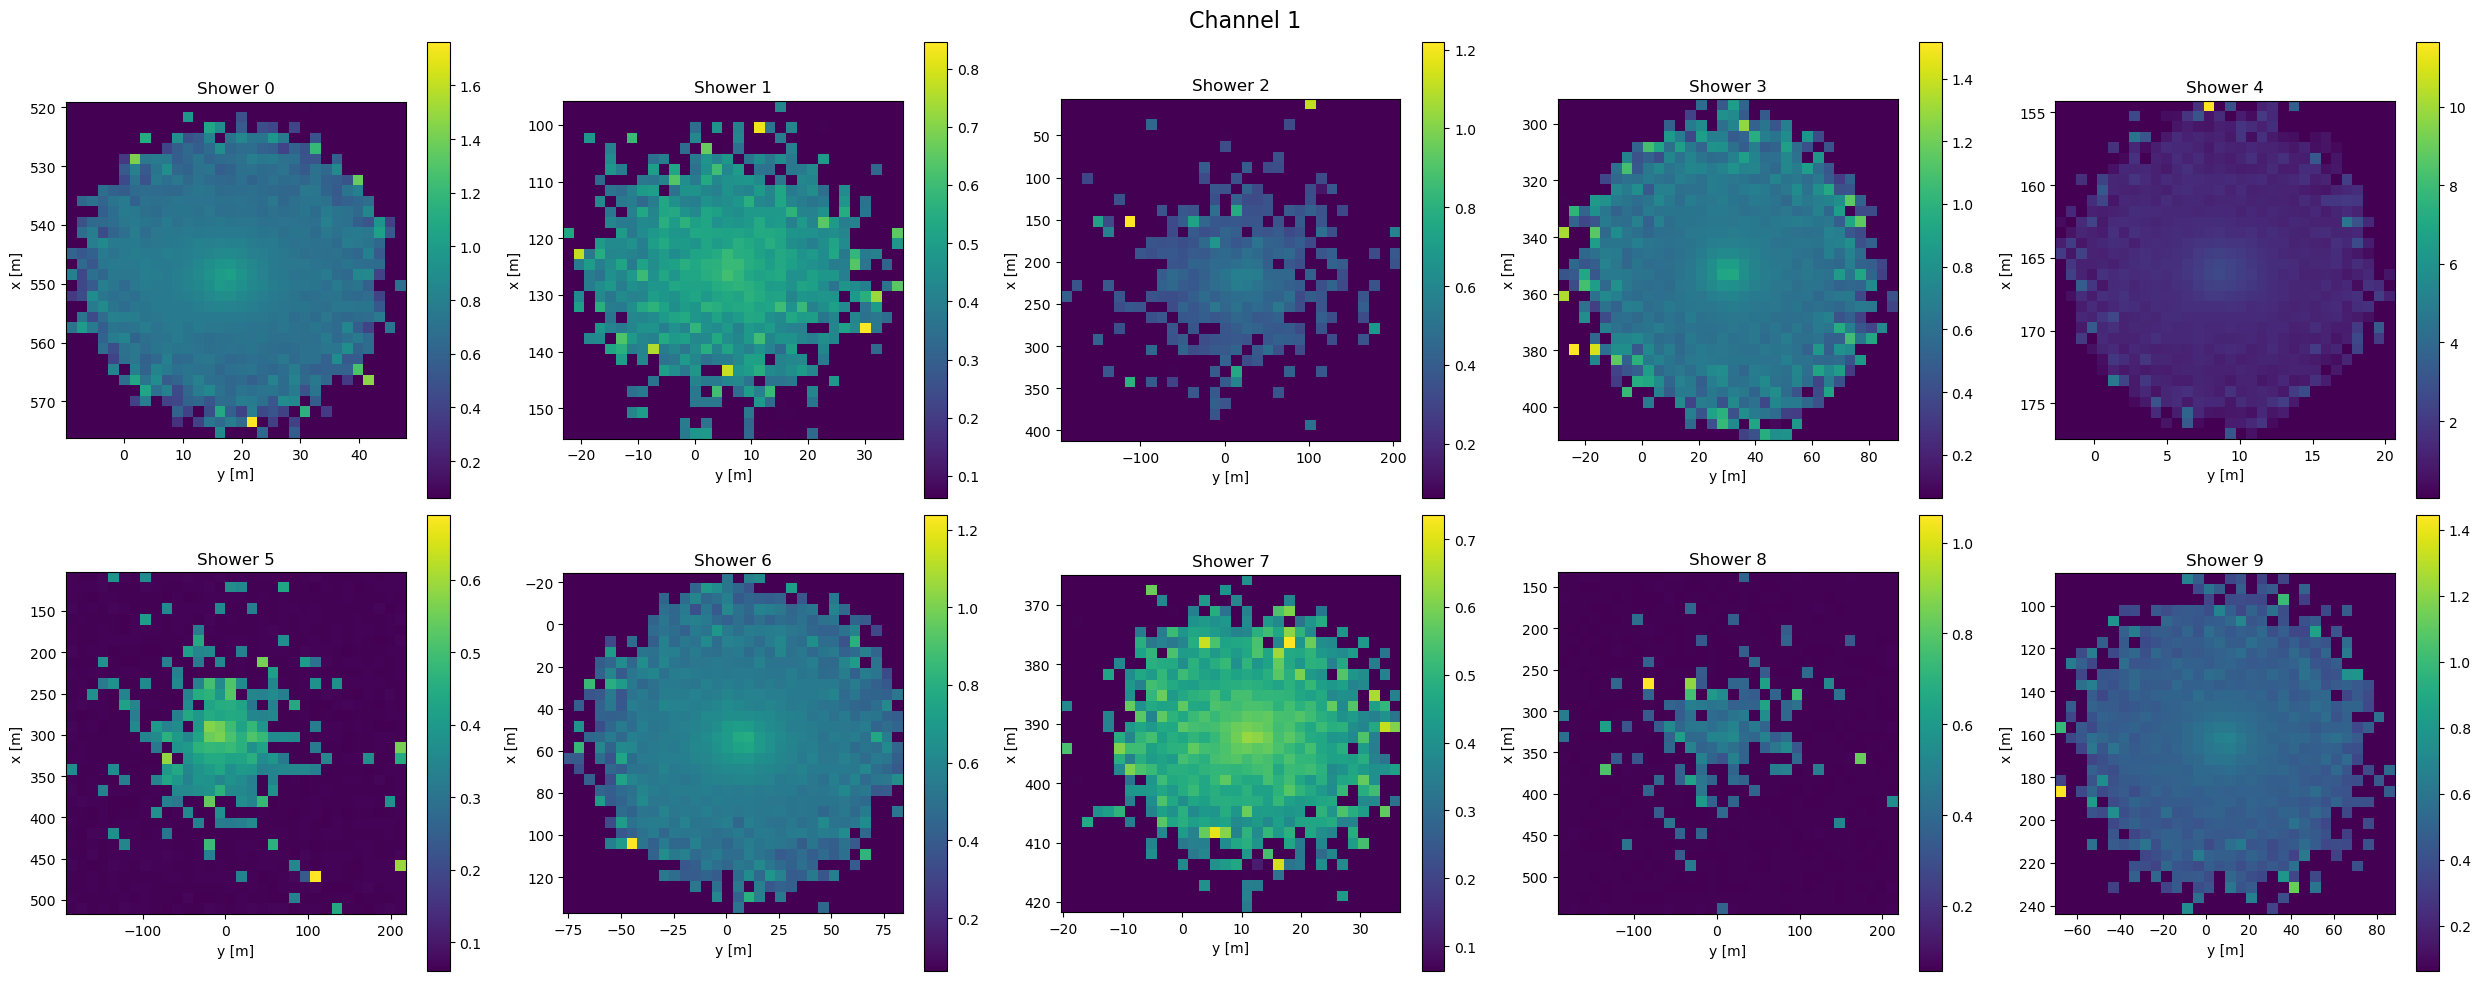

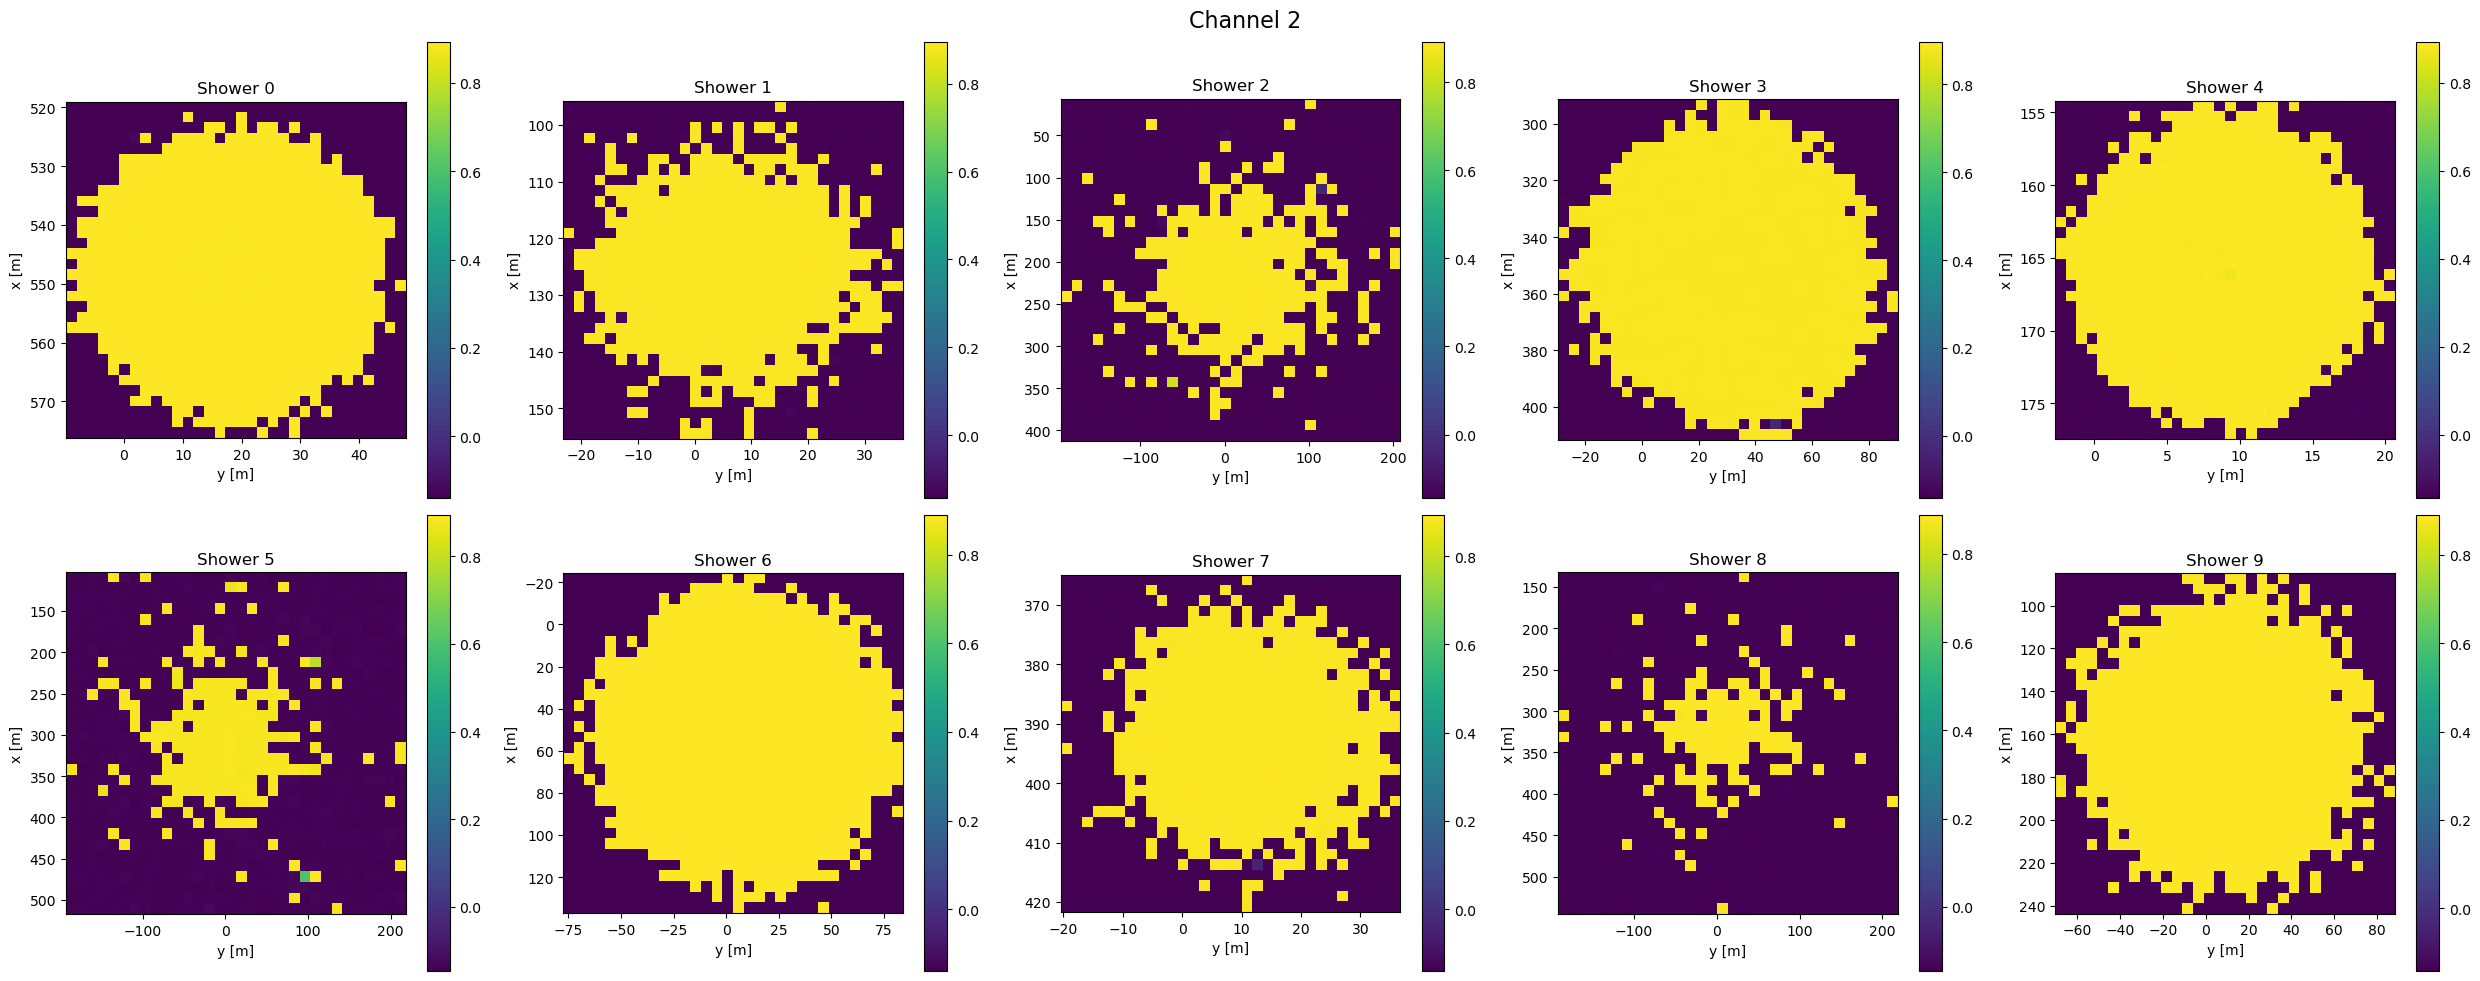

In [8]:
SWGOopt = False
N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x, y, True, number_of_showers=10)

In [9]:
print("N:", N.shape)
print("T:", T.shape)
print("X0:", X0)
print("Y0:", Y0)
print("E:", energy.shape)

N: torch.Size([10, 500])
T: torch.Size([10, 500])
X0: tensor([547.5815, 124.9040, 207.6498, 350.1962, 165.3235, 301.9958,  52.4574,
        391.4819, 326.9137, 160.5637])
Y0: tensor([17.4028,  5.2515,  5.5670, 28.1287,  8.3194, -0.5535,  4.8312,  9.5876,
         3.6122,  6.1459])
E: torch.Size([10])


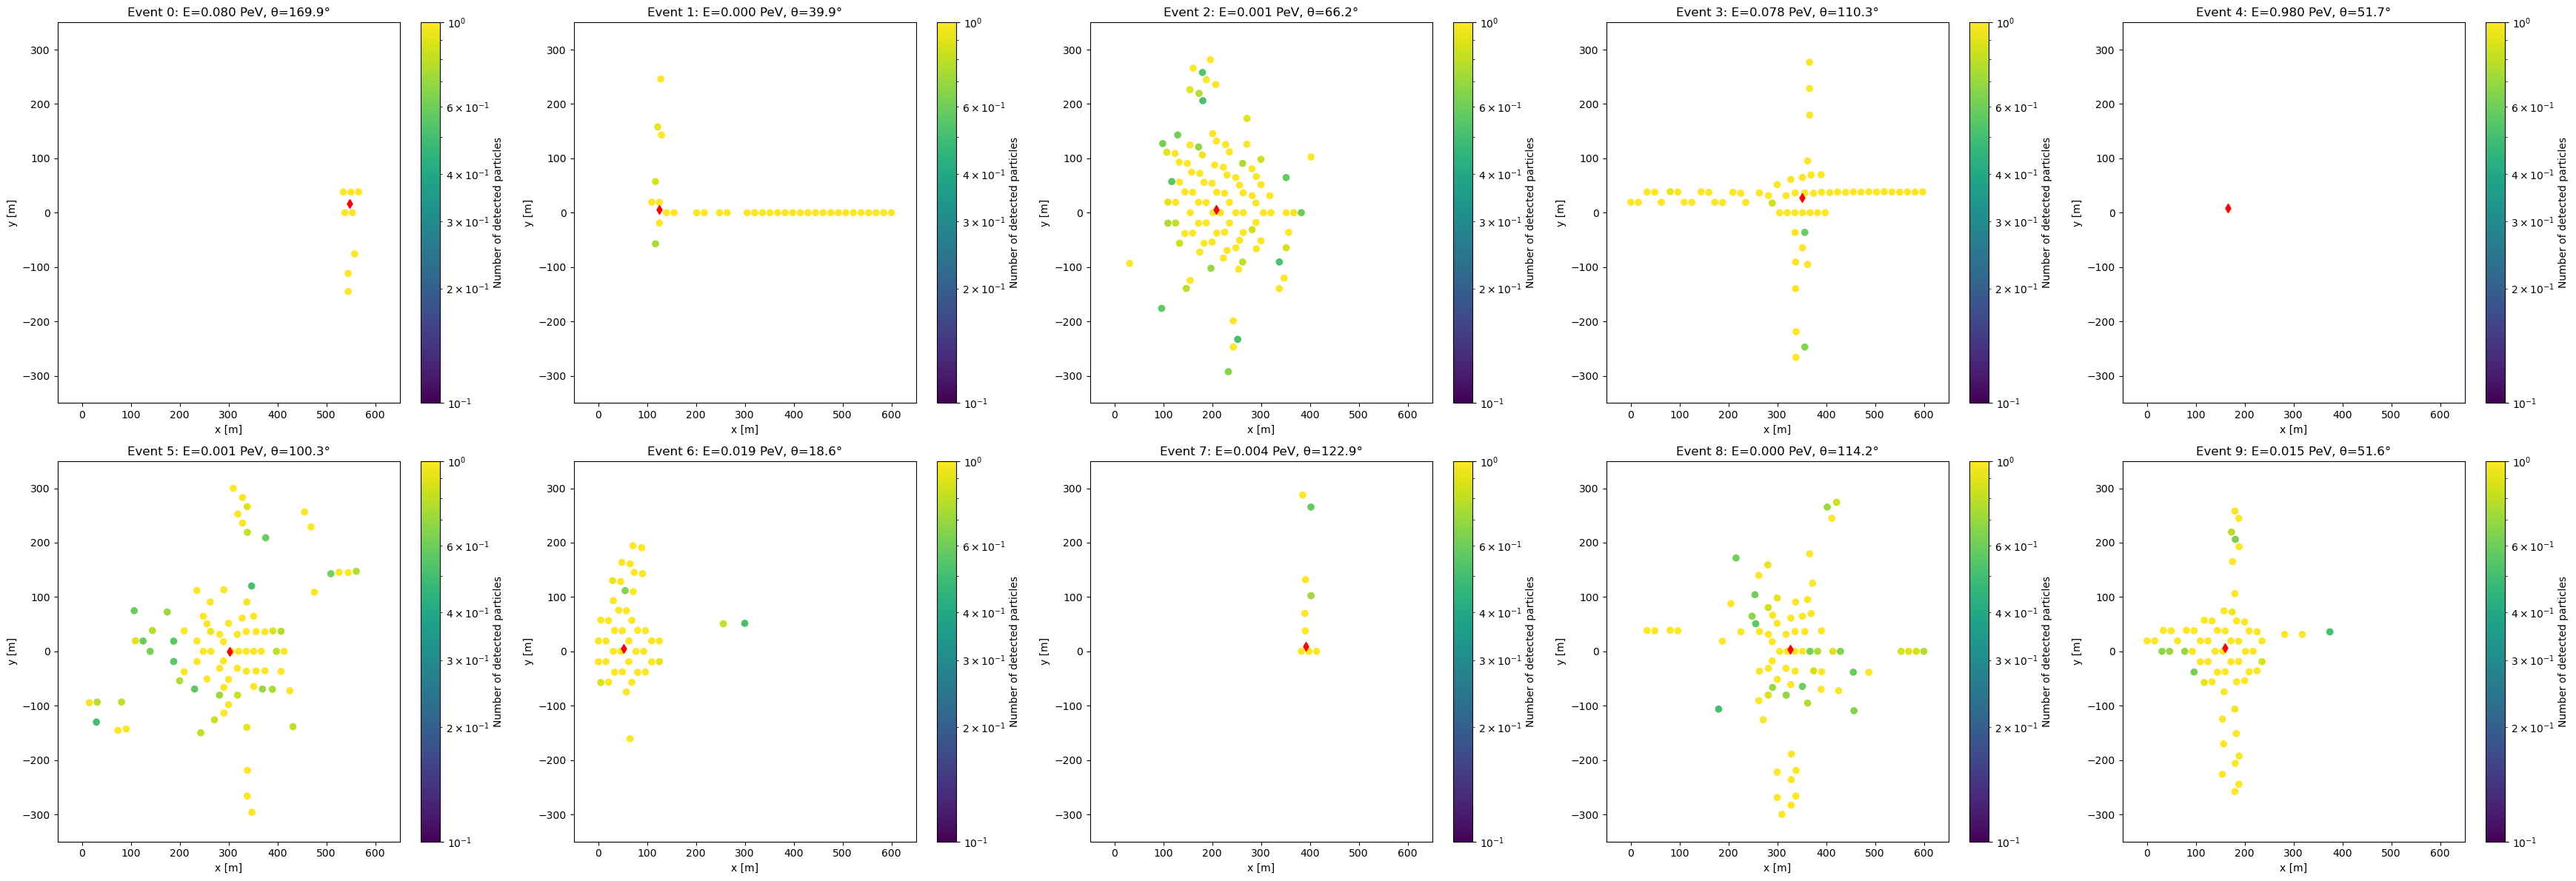

In [10]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    idx = torch.where(N_tmp >= 5e-1)[0]
    norm = LogNorm(vmin=0.1, vmax=1)

    scatter = axes[i].scatter(x[idx], y[idx], c=N_tmp[idx], cmap="viridis", norm=norm)
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Number of detected particles')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# x = torch.linspace(0, 2, 100)
# plt.plot(x, torch.sigmoid(2 * (x -0.1)))

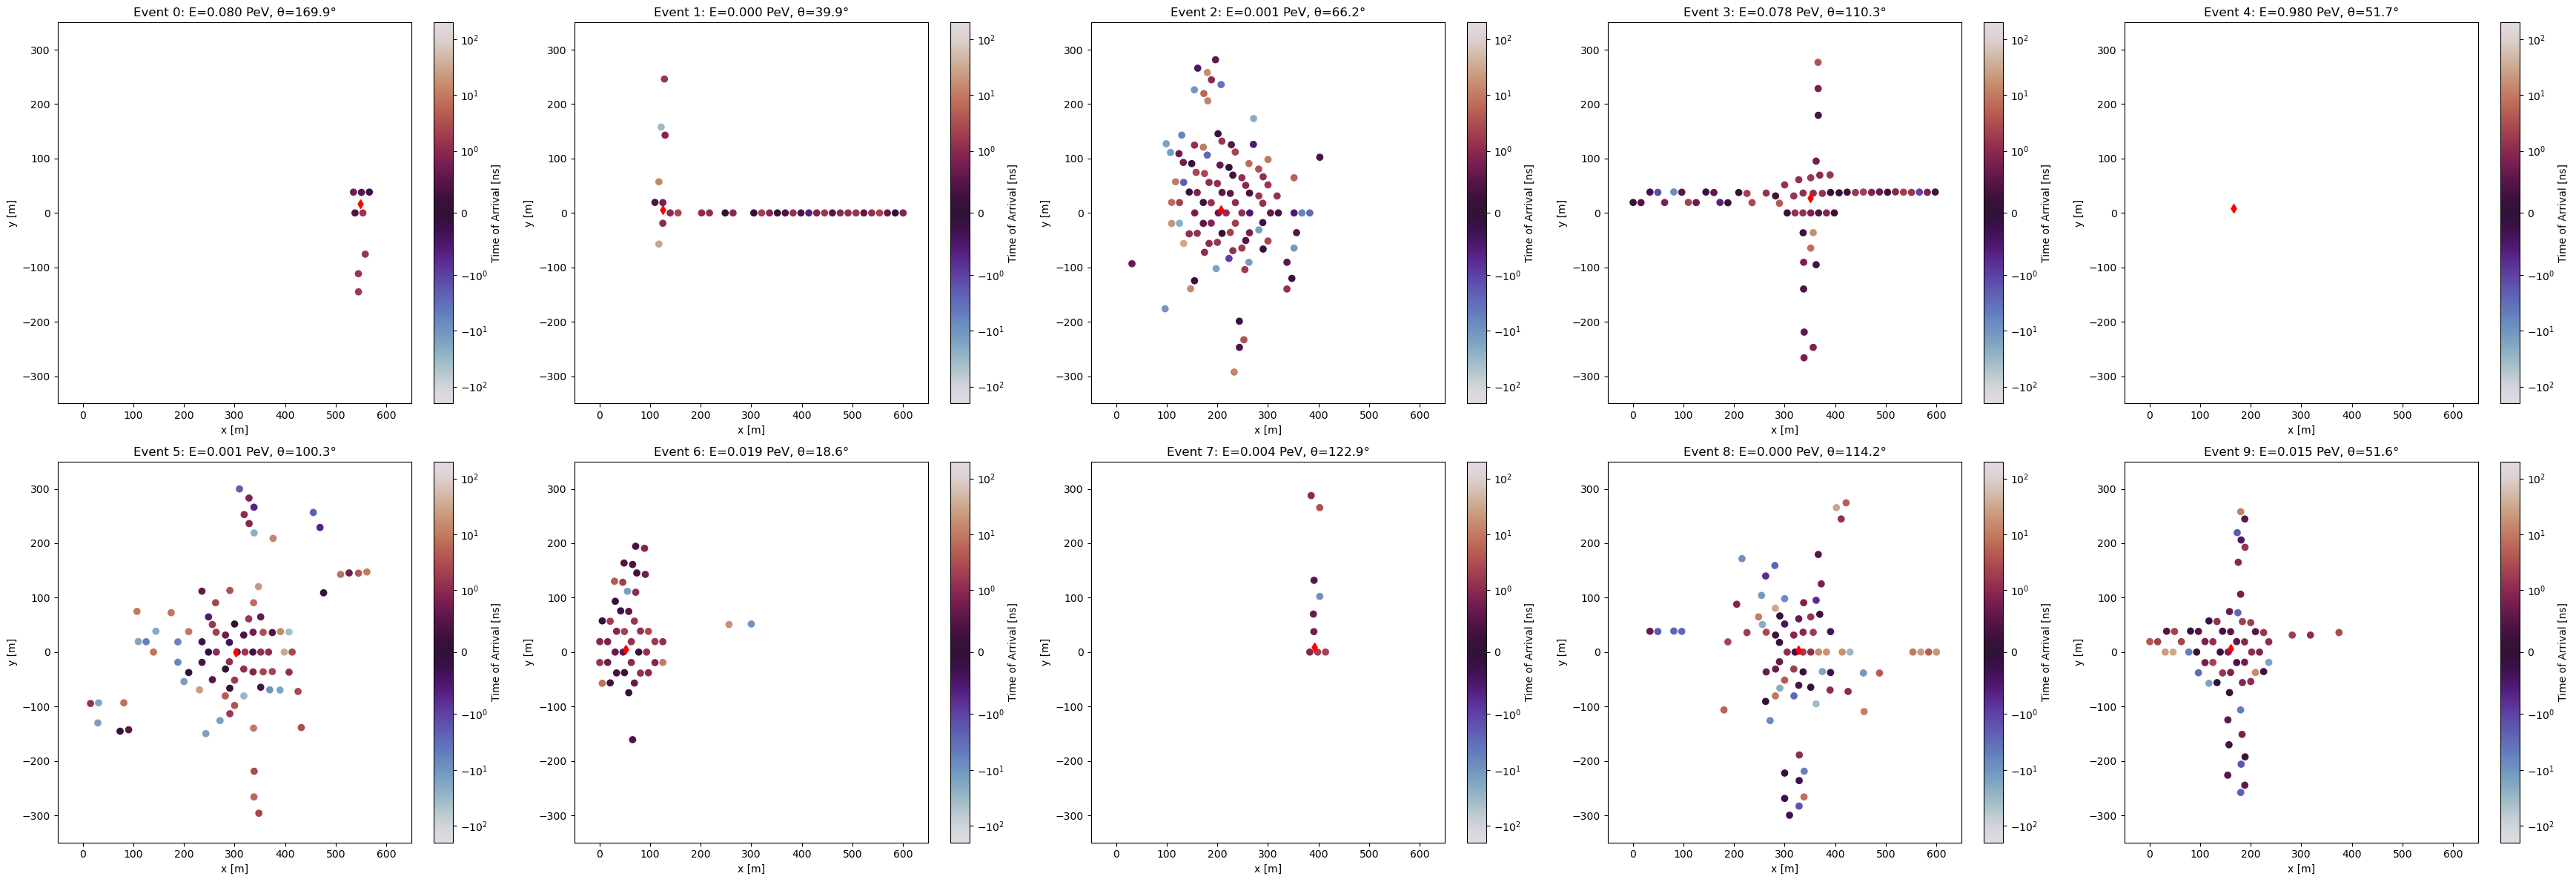

In [12]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes  = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 5e-1)[0]
    from matplotlib.colors import SymLogNorm
    norm = SymLogNorm(linthresh=1, vmin=-200, vmax=200)


    scatter = axes[i].scatter(x[idx], y[idx], c=T_tmp[idx], cmap="twilight", norm=norm)
    axes[i].scatter(X0[i].item(), Y0[i].item(), c="red", marker="d")
    fig.colorbar(scatter, ax=axes[i], label='Time of Arrival [ns]')
    axes[i].set_xlabel("x [m]"); axes[i].set_ylabel("y [m]")
    axes[i].set_xlim((-50, 650)); axes[i].set_ylim((-350, 350))
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

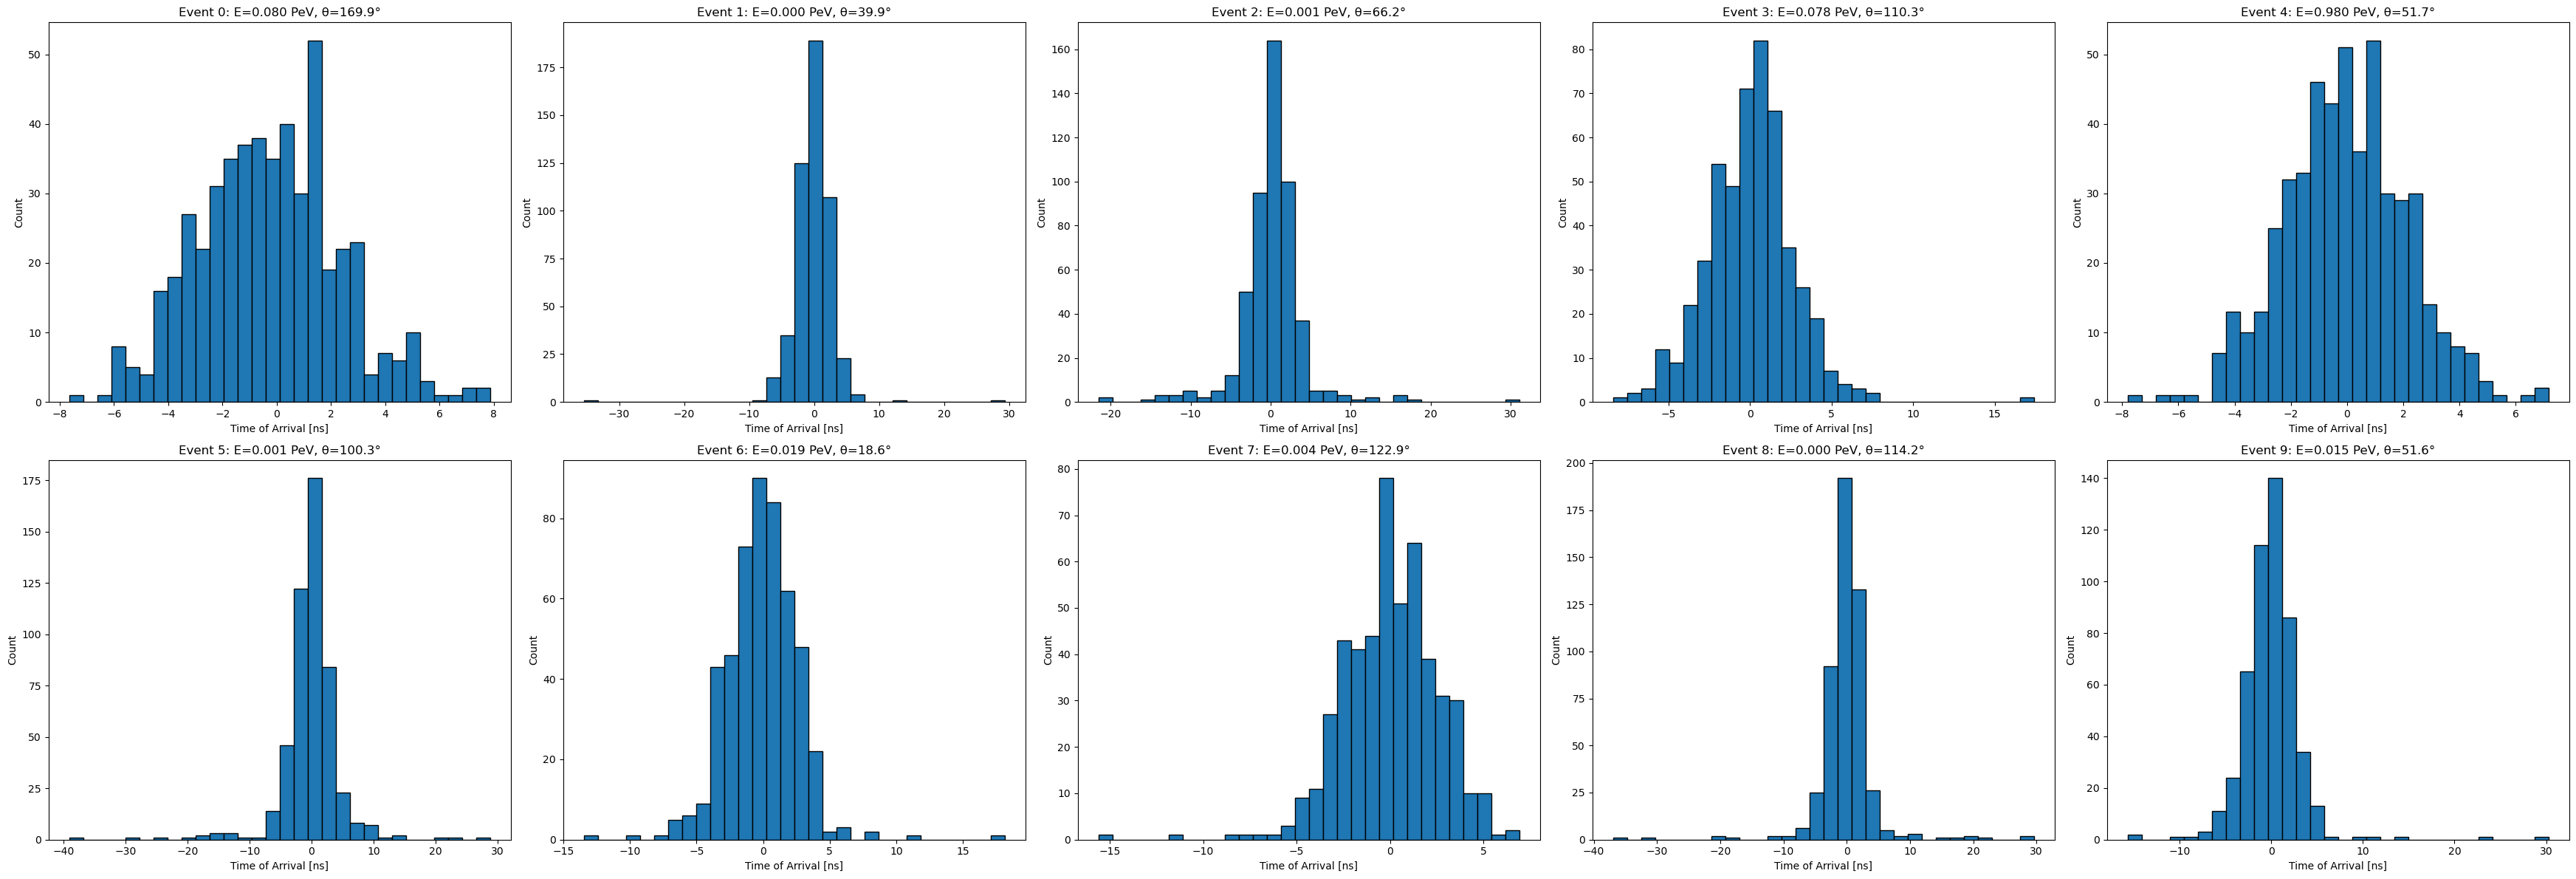

In [13]:
th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

n_events = N.shape[0]
ncols = 5
nrows = (n_events + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = axes.flatten()

for i in range(n_events):
    N_tmp = N[i]
    T_tmp = T[i]
    idx = torch.where(N_tmp >= 1e-2)[0]
    axes[i].hist(T_tmp[idx].detach().cpu().numpy(), bins=30, edgecolor='black')
    axes[i].set_xlabel("Time of Arrival [ns]")
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Event {i}: E={energy[i].item():.3f} PeV, θ={th[i].item()*180/np.pi:.1f}°")

for i in range(n_events, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


## Generate Training Data

In [14]:
%%time

N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x, y, False, number_of_showers=Nevents)

th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
x0 = X0 / 5000
y0 = Y0 / 5000

x_exp = x.unsqueeze(0).expand(Nevents, -1)
y_exp = y.unsqueeze(0).expand(Nevents, -1)

inputs = torch.stack([x_exp, y_exp, N, T], dim=2).float()
labels = torch.stack([x0, y0, E_norm, theta_norm, phi_norm], dim=1).float()

Processing conditions 0 to 5000 / 20000...


Processing conditions 5000 to 10000 / 20000...


Processing conditions 10000 to 15000 / 20000...


Processing conditions 15000 to 20000 / 20000...


✔ Done: generated 20000 showers across 20000 conditions.
Total generation time: 3635.03s
Done: generated 20000 bbox predictions across 20000 conditions.
Total generation time: 0.03s


CPU times: user 28min 46s, sys: 31min 36s, total: 1h 23s
Wall time: 1h 36s


In [15]:
os.makedirs(output_dir, exist_ok=True)
torch.save(inputs, f"{output_dir}/inputs.pt")
torch.save(labels, f"{output_dir}/labels.pt")

## Generate Validation Data

In [16]:
%%time

N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x, y, False, number_of_showers=Nvalidation)

th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
x0 = X0 / 5000
y0 = Y0 / 5000

x_exp = x.unsqueeze(0).expand(Nvalidation, -1)
y_exp = y.unsqueeze(0).expand(Nvalidation, -1)

inputs_val = torch.stack([x_exp, y_exp, N, T], dim=2).float()
labels_val = torch.stack([x0, y0, E_norm, theta_norm, phi_norm], dim=1).float()

Processing conditions 0 to 2000 / 2000...


✔ Done: generated 2000 showers across 2000 conditions.
Total generation time: 365.69s
Done: generated 2000 bbox predictions across 2000 conditions.
Total generation time: 0.01s
CPU times: user 2min 57s, sys: 3min 7s, total: 6min 5s
Wall time: 6min 5s


In [17]:
torch.save(inputs_val, f"{output_dir}/inputs_val.pt")
torch.save(labels_val, f"{output_dir}/labels_val.pt")

## Load Cached Data (optional)

In [18]:
inputs = torch.load(f"{output_dir}/inputs.pt")
labels = torch.load(f"{output_dir}/labels.pt")
inputs_val = torch.load(f"{output_dir}/inputs_val.pt")
labels_val = torch.load(f"{output_dir}/labels_val.pt")

## Train Reconstruction NN

In [19]:
model = Reconstruction(num_detectors=Nunits)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

In [20]:
dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=False, num_workers=4)

/n/home05/zdimitrov/.conda/envs/multiproc_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training is 10% done, with Loss = 0.87


Training is 20% done, with Loss = 0.68


Training is 30% done, with Loss = 0.68


Training is 40% done, with Loss = 0.68


Training is 50% done, with Loss = 0.68


Training is 60% done, with Loss = 0.68


Training is 70% done, with Loss = 0.68


Training is 80% done, with Loss = 0.69


Training is 90% done, with Loss = 0.69


Training is 100% done, with Loss = 0.69
CPU times: user 13min 29s, sys: 1min 15s, total: 14min 44s
Wall time: 16min 7s


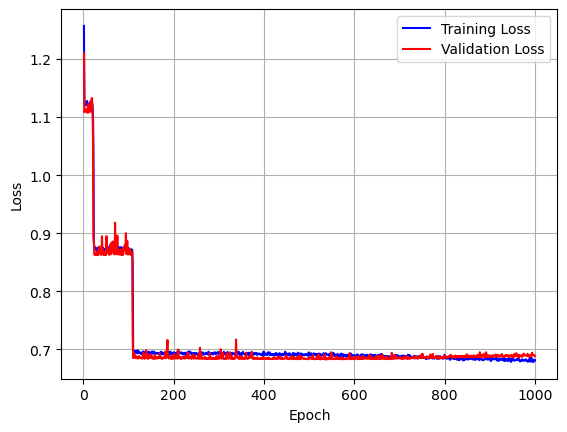

In [21]:
%%time

val_losses = []
losses = []
early_stopper = EarlyStopping()

for num_epoch in range(1000):
    epoch_loss = 0
    total_batch = 0
    
    for batch_inputs, batch_labels in dataloader:
        batch_size = batch_inputs.size(0)
        train_x = batch_inputs.view(batch_size, -1)
        train_y = batch_labels.view(batch_size, -1)
        
        outputs = model(train_x)
        loss = criterion(outputs, train_y)
        epoch_loss += loss.item()
        total_batch += 1

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    val_size = inputs_val.size(0)
    val_x = inputs_val.view(val_size, -1)
    val_y = labels_val.view(val_size, -1)

    model.eval()
    with torch.no_grad():
        val_output = model(val_x)
        val_loss = criterion(val_output, val_y)
    
    val_losses.append(val_loss.item())
    early_stopper(val_loss)

    if (num_epoch + 1) % 100 == 0:
        print(f"Training is {int((num_epoch + 1) / 10)}% done, with Loss = {val_loss:.2f}")

    losses.append(epoch_loss / total_batch)

plt.plot(np.arange(1, len(losses) + 1), losses, color="blue", label="Training Loss")
plt.plot(np.arange(1, len(val_losses) + 1), val_losses, color="red", label="Validation Loss")
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid()

In [22]:
torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")

## Evaluate Reconstruction

In [23]:
model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))

Ntest = 300#0
N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x, y, False, number_of_showers=Ntest)

th = torch.atan2(sin_z, cos_z)
ph = torch.atan2(sin_a, cos_a)

E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
x0 = X0 / 5000
y0 = Y0 / 5000

x_exp = x.unsqueeze(0).expand(Ntest, -1)
y_exp = y.unsqueeze(0).expand(Ntest, -1)

inputs_test = torch.stack([x_exp, y_exp, N, T], dim=2).float()
labels_test = torch.stack([x0, y0, E_norm, theta_norm, phi_norm], dim=1).float()

Processing conditions 0 to 300 / 300...


✔ Done: generated 300 showers across 300 conditions.
Total generation time: 59.28s
Done: generated 300 bbox predictions across 300 conditions.
Total generation time: 0.07s


In [24]:
model.eval()
with torch.no_grad():
    outputs = model(inputs_test.view(Ntest, -1))

In [25]:
x_pred = outputs[:, 0]
y_pred = outputs[:, 1]
E_pred, theta_pred, phi_pred = DenormalizeLabels(outputs[:, 2], outputs[:, 3], outputs[:, 4])

E_p, E_r = E_pred, energy
X_r, X_p = X0, x_pred * 5000
Y_r, Y_p = Y0, y_pred * 5000
Th_r, Th_p = th, theta_pred
Ph_r, Ph_p = ph, phi_pred

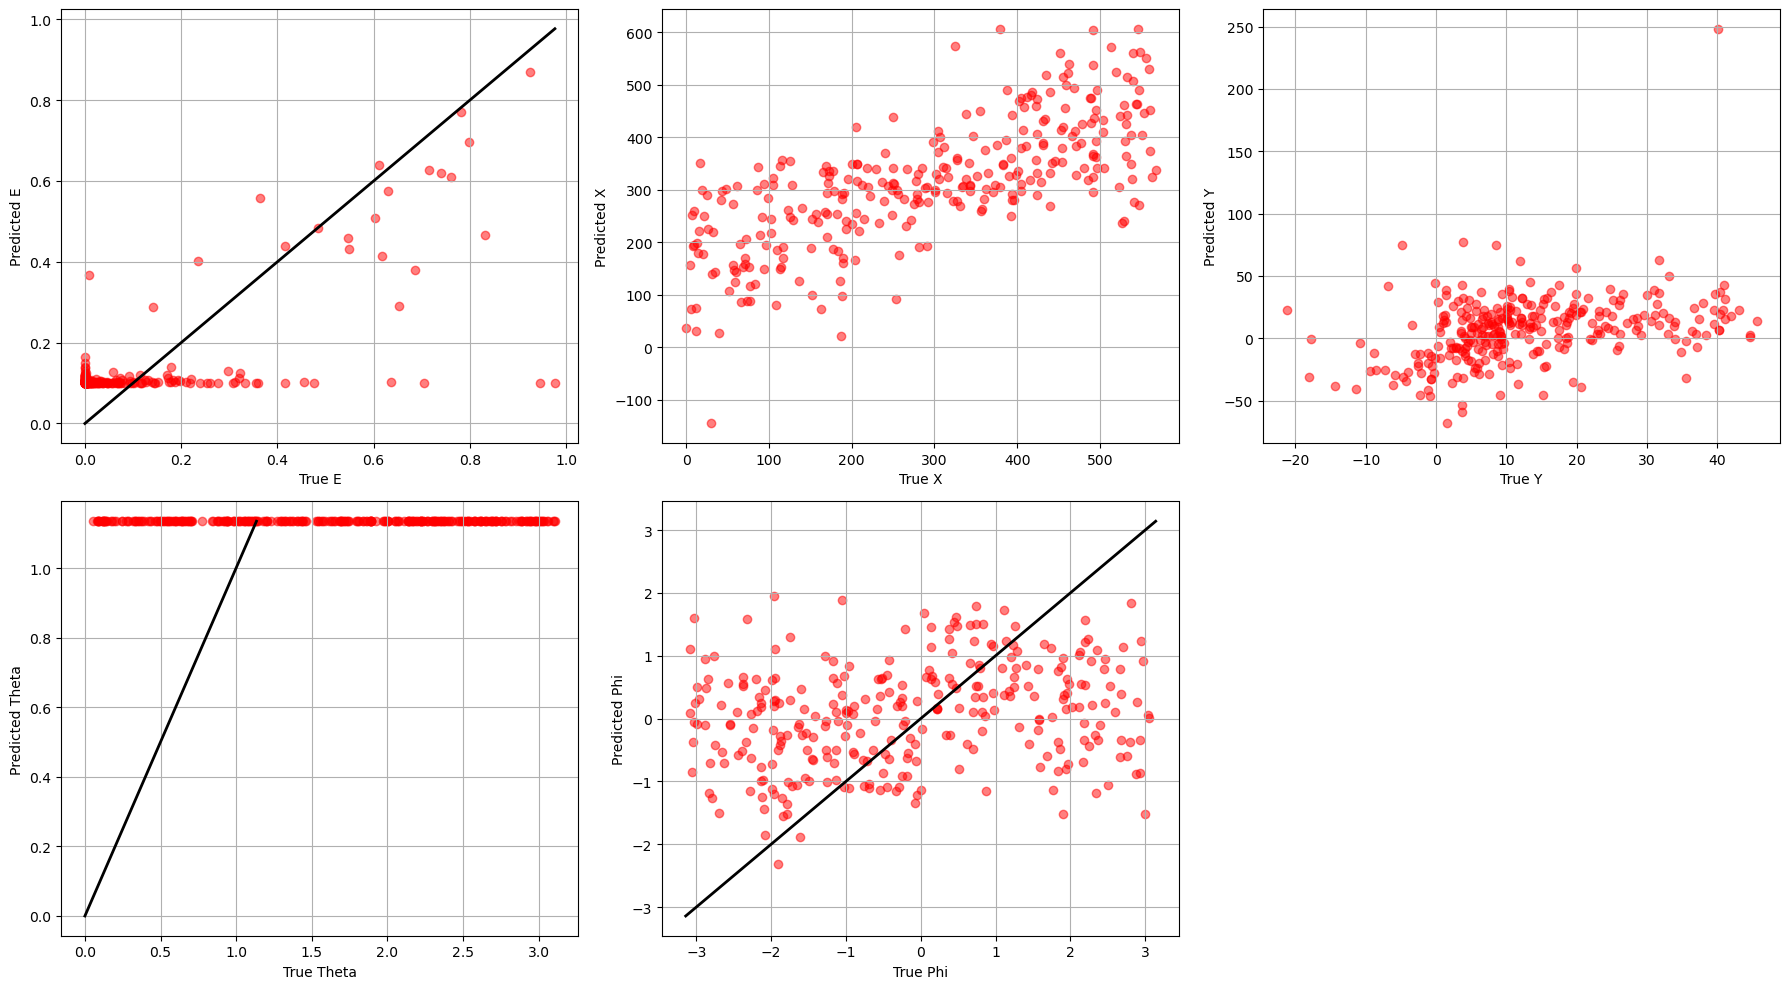

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(E_r, E_p, alpha=.5, color="r")
axes[0, 0].plot([0, E_r.max()], [0, E_r.max()], "k-", lw=2)
axes[0, 0].set_xlabel("True E"); axes[0, 0].set_ylabel("Predicted E"); axes[0, 0].grid()

axes[0, 1].scatter(X_r, X_p.detach(), alpha=.5, color="r")
axes[0, 1].set_xlabel("True X"); axes[0, 1].set_ylabel("Predicted X"); axes[0, 1].grid()

axes[0, 2].scatter(Y_r, Y_p.detach(), alpha=.5, color="r")
axes[0, 2].set_xlabel("True Y"); axes[0, 2].set_ylabel("Predicted Y"); axes[0, 2].grid()

axes[1, 0].scatter(Th_r, Th_p.detach(), alpha=.5, color="r")
axes[1, 0].plot([0, np.pi*65/180], [0, np.pi*65/180], "k-", lw=2)
axes[1, 0].set_xlabel("True Theta"); axes[1, 0].set_ylabel("Predicted Theta"); axes[1, 0].grid()

axes[1, 1].scatter(Ph_r, Ph_p.detach(), alpha=.5, color="r")
axes[1, 1].plot([-np.pi, np.pi], [-np.pi, np.pi], "k-", lw=2)
axes[1, 1].set_xlabel("True Phi"); axes[1, 1].set_ylabel("Predicted Phi"); axes[1, 1].grid()

axes[1, 2].axis("off")
plt.tight_layout(); plt.show()

## Load/Initialize Model for Optimization

In [27]:
torch.save(model.state_dict(), f"{output_dir}/model_weights.pth")

model = Reconstruction(num_detectors=Nunits)

path = Path(f"{output_dir}/checkpoint.pth")
if path.exists():
    checkpoint = torch.load(f"{output_dir}/checkpoint.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Updated Weights are loaded")
else:
    model.load_state_dict(torch.load(f"{output_dir}/model_weights.pth"))
    print("Initial Weights are loaded")

Updated Weights are loaded


## Initialize Learnable Layout

In [28]:
e = 0
os.makedirs(f"{output_dir}/Python_Layout", exist_ok=True)

for i in range(1000):
    p_layout = Path(f"{output_dir}/Python_Layout/Layout_{i + 1}.txt")
    if p_layout.exists():
        data = np.loadtxt(p_layout)
        x = torch.tensor(data[:, 0], dtype=torch.float32)
        y = torch.tensor(data[:, 1], dtype=torch.float32)
        e = i + 1

if e > 0:
    print(f"Updated Layout {e} is initialized")
else:
    print("First Layout is initialized")

xy_module = LearnableXY(x, y)

Updated Layout 150 is initialized


## Layout Optimization Loop

In [29]:
%%time

SWGOopt = True
optimizer = torch.optim.SGD(xy_module.parameters(), lr=5, momentum=.9)

if path.exists():
    checkpoint = torch.load(path)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    num_epoch = checkpoint.get("epoch") + 1
    loss = checkpoint.get("loss")
    print(f"Optimizer is initialized from the last epoch {num_epoch}")
else:
    num_epoch = 0
    print("Optimizer is initialized")

max_grad = 10.
Nbatch = 50#0

if num_epoch < 20:
    Nfinetune = 250#0
elif num_epoch >= 20:
    Nfinetune = 500#0

U_vals = []
U_pr_vals = []
U_e_vals = []
U_th_vals = []

for epoch in range(num_epoch, num_epoch + 150):
    x1, y1 = xy_module()
    
    N_list, T_list, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x1, y1, False, number_of_showers=Nbatch)
    
    th = torch.atan2(sin_z, cos_z)
    ph = torch.atan2(sin_a, cos_a)

    E_norm, theta_norm, phi_norm = NormalizeLabels(energy, th, ph)
    x0 = X0 / 5000
    y0 = Y0 / 5000

    x = x1.unsqueeze(0).repeat(Nbatch, 1)
    y = y1.unsqueeze(0).repeat(Nbatch, 1)
    
    labels_batch = torch.stack([x0, y0, E_norm, theta_norm, phi_norm], dim=1).float()
    events_batch = torch.stack((x, y, N_list, T_list), dim=2)
    
    model.eval()
    preds_batch = model(events_batch.view(Nbatch, -1))

    preds_x = preds_batch[:, 0] * 5000
    preds_y = preds_batch[:, 1] * 5000
    preds_e, preds_th, preds_phi = DenormalizeLabels(preds_batch[:, 2], preds_batch[:, 3], preds_batch[:, 4])

    r_score = reconstructability(events_batch[:, :, 2])
    density = Nbatch / ((labels_batch[:, 0].max() - labels_batch[:, 0].min()) * 
                        (labels_batch[:, 1].max() - labels_batch[:, 1].min()))

    U = 1e-2 * U_TH(preds_th, labels_batch[:, 3], r_score) + U_E(preds_e, labels_batch[:, 2], r_score) + U_PR(r_score) / torch.sqrt(density)

    U_vals.append(U.item())
    U_pr_vals.append((U_PR(r_score) / torch.sqrt(density)).item())
    U_e_vals.append(U_E(preds_e, labels_batch[:, 2], r_score).item())
    U_th_vals.append(1e-2 * U_TH(preds_th, labels_batch[:, 3], r_score).item())

    print(f"Utility: {U:.2f}")

    Loss = -U
    Loss.backward()

    torch.nn.utils.clip_grad_norm_(xy_module.parameters(), max_norm=max_grad)
    optimizer.step()

    with torch.no_grad():
        push_apart(xy_module, min_dist=2 * TankRadius)

    optimizer.zero_grad()

    # Fine-tune NN every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Fine Tune at epoch {epoch + 1}")
        
        with torch.no_grad():
            x2, y2 = xy_module()
            x_ft = x2.detach()
            y_ft = y2.detach()

            N, T, X0, Y0, energy, sin_z, cos_z, sin_a, cos_a = generate_showers(x_ft, y_ft, False, number_of_showers=Nfinetune)
            
            theta = torch.atan2(sin_z, cos_z)
            phi = torch.atan2(sin_a, cos_a)
            energy, theta, phi = NormalizeLabels(energy, theta, phi)
            X0 /= 5000
            Y0 /= 5000

            finetune_trues = torch.stack([X0, Y0, energy, theta, phi], dim=1)
            
            x_exp = x_ft.unsqueeze(0).expand(Nfinetune, -1)
            y_exp = y_ft.unsqueeze(0).expand(Nfinetune, -1)
            finetune_events = torch.stack((x_exp, y_exp, N, T), dim=2)

        ReconstructionNN = model
        ReconstructionNN.train()
        criterion = nn.MSELoss()
        optimizerNN = torch.optim.Adam(ReconstructionNN.parameters(), lr=5e-5)

        ft_dataset = TensorDataset(finetune_events, finetune_trues)
        ft_dataloader = DataLoader(ft_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=4)

        for j in range(5):
            for ft_batch, ft_trues in ft_dataloader:
                batch_size = ft_batch.size(0)
                train_x = ft_batch.view(batch_size, -1)
                train_y = ft_trues.view(batch_size, 5)
                outputs = ReconstructionNN(train_x)
                lossT = criterion(outputs, train_y)
                lossT.backward()
                optimizerNN.step()
                optimizerNN.zero_grad()

    torch.save({"epoch": epoch, "loss": Loss, "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict()}, f"{output_dir}/checkpoint.pth")
    
    np.savetxt(f"{output_dir}/Python_Layout/Layout_{epoch + 1}.txt",
               np.column_stack((x1.detach().numpy(), y1.detach().numpy())))

Optimizer is initialized from the last epoch 150
Processing conditions 0 to 50 / 50...


✔ Done: generated 50 showers across 50 conditions.
Total generation time: 12.51s
Done: generated 50 bbox predictions across 50 conditions.
Total generation time: 0.00s
Utility: 399.51
Processing conditions 0 to 50 / 50...


✔ Done: generated 50 showers across 50 conditions.
Total generation time: 12.47s
Done: generated 50 bbox predictions across 50 conditions.
Total generation time: 0.00s
Utility: 42.49
Processing conditions 0 to 50 / 50...


✔ Done: generated 50 showers across 50 conditions.
Total generation time: 12.49s
Done: generated 50 bbox predictions across 50 conditions.
Total generation time: 0.00s
Utility: 43.83
Processing conditions 0 to 50 / 50...


✔ Done: generated 50 showers across 50 conditions.
Total generation time: 12.46s
Done: generated 50 bbox predictions across 50 conditions.
Total generation time: 0.00s
Utility: 42.80
Processing conditions 0 to 50 / 50...


...

✔ Done: generated 50 showers across 50 conditions.
Total generation time: 12.46s
Done: generated 50 bbox predictions across 50 conditions.
Total generation time: 0.00s
Utility: 46.15
Processing conditions 0 to 50 / 50...


✔ Done: generated 50 showers across 50 conditions.
Total generation time: 12.46s
Done: generated 50 bbox predictions across 50 conditions.
Total generation time: 0.00s
Utility: 986.59
Processing conditions 0 to 50 / 50...


✔ Done: generated 50 showers across 50 conditions.
Total generation time: 13.24s
Done: generated 50 bbox predictions across 50 conditions.
Total generation time: 0.00s
Utility: 46.11
Fine Tune at epoch 300
Processing conditions 0 to 500 / 500...


✔ Done: generated 500 showers across 500 conditions.
Total generation time: 95.24s
Done: generated 500 bbox predictions across 500 conditions.
Total generation time: 0.00s


CPU times: user 57min 16s, sys: 21min 41s, total: 1h 18min 58s
Wall time: 1h 19min 36s


## Visualize Results

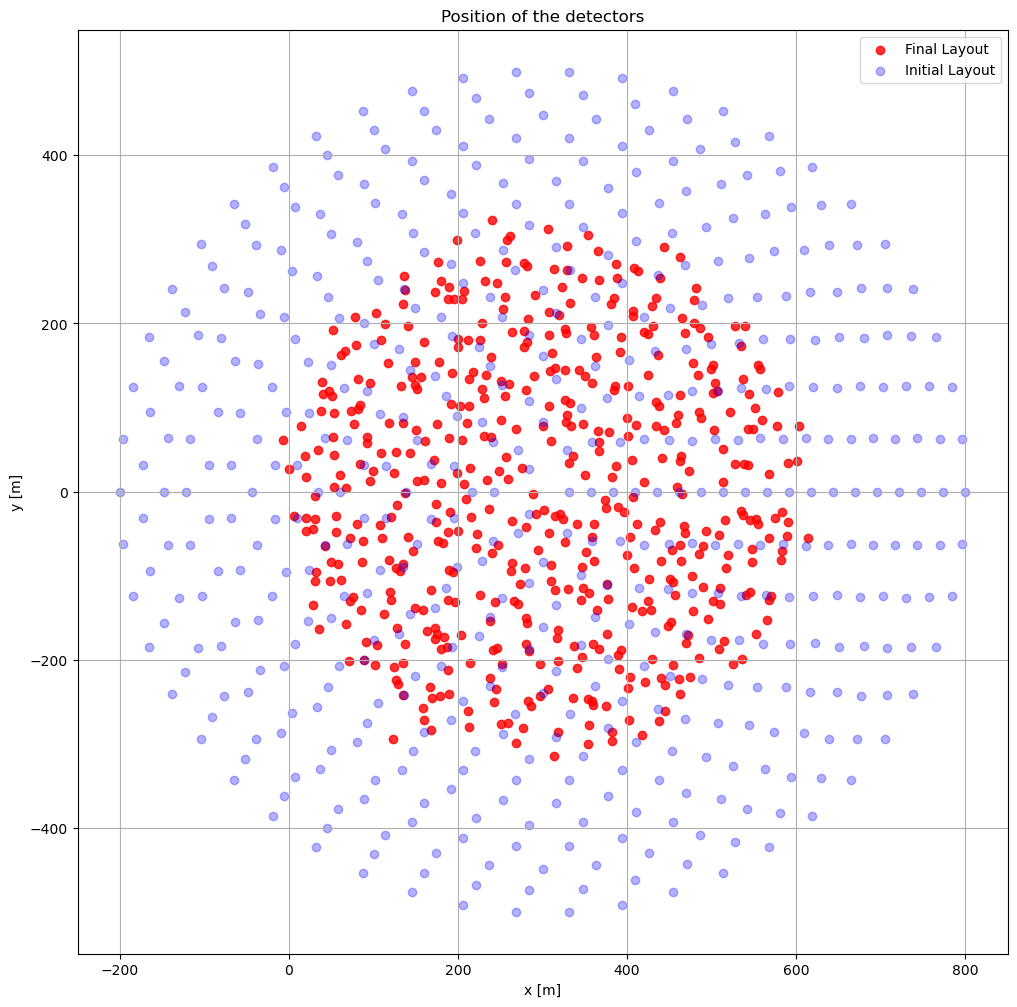

In [30]:
a, b = Layouts(n_detectors=Nunits, n_rings=20)

plt.figure(figsize=[12, 12])
plt.scatter(x1.detach() if 'x1' in dir() else x.detach(), 
            y1.detach() if 'y1' in dir() else y.detach(), color="red", alpha=.8, label="Final Layout")
plt.scatter(a, b, color="blue", alpha=.3, label="Initial Layout")
plt.grid(); plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.title("Position of the detectors"); plt.legend()
plt.show()

In [31]:
utility_path = Path(f"{output_dir}/Python_Layout/Utilities.txt")

if utility_path.exists():
    u_t = np.loadtxt(utility_path)
    u_t = np.append(u_t, np.array(U_vals).ravel())
    np.savetxt(utility_path, u_t)
else:
    u_t = U_vals
    np.savetxt(utility_path, u_t)

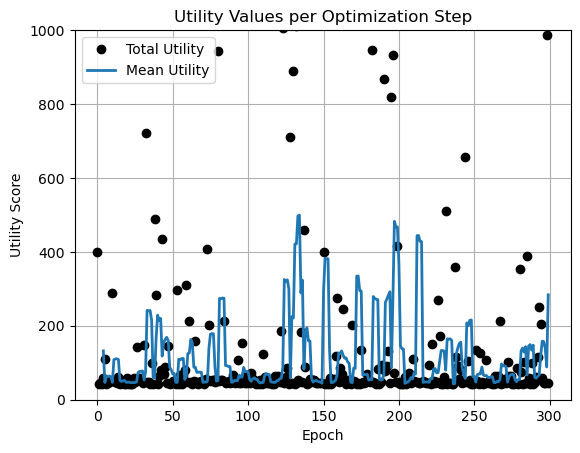

In [32]:
mean_ut = [np.mean(u_t[i - 4: i]) for i in range(4, len(u_t))]

plt.plot(u_t, color="black", linestyle="none", marker="o", linewidth=.5, label="Total Utility")
plt.plot(np.arange(4, len(u_t)), mean_ut, linestyle="-", linewidth=2, label="Mean Utility")
plt.legend(); plt.grid()
plt.xlabel("Epoch"); plt.ylabel("Utility Score")
plt.ylim((-0.1, 1000.2))
plt.title("Utility Values per Optimization Step")
plt.show()